In [1]:
import json
import plotly.graph_objects as go
import plotly.io as pio
import ipywidgets as widgets
from IPython.display import display

# Force Plotly to use the dedicated Google Colab rendering engine
pio.renderers.default = "colab"

# 1. Load the trace map
# INPUT_JSON_PATH = "/content/drive/MyDrive/ResearchProject/trace_map.json"
INPUT_JSON_PATH = "../data/processed/trace_map.json"
with open(INPUT_JSON_PATH, "r") as f:
    trace_map = json.load(f)

# 2. Prepare the dropdown options
dropdown_options = {}
for article_id, data in trace_map.items():
    snippet = data['text'][:50].replace('\n', ' ') + "..."
    label = f"Article {article_id} - {snippet}"
    dropdown_options[label] = article_id

# 3. Create a sandbox output area to prevent rendering blocks in Colab
output_area = widgets.Output()

# 4. Define the plotting function
def plot_saliency_map(selected_article_id):
    # Clear the previous visualization safely
    output_area.clear_output(wait=True)

    with output_area:
        # Extract data for the selected article
        data = trace_map[selected_article_id]
        scores = data['all_layer_scores']
        n_layers = len(scores)

        # Dynamic Sorting: Find the indices of the top 3 highest scores
        top_3_layers = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:3]

        # Create the color array (Red for the dynamic top 3 layers, else Blue)
        marker_colors = ['#ef4444' if idx in top_3_layers else '#3b82f6' for idx in range(n_layers)]

        # Generate the Plotly figure
        fig = go.Figure(data=[
            go.Bar(
                x=list(range(n_layers)),
                y=scores,
                marker_color=marker_colors,
                name="Recovery Score"
            )
        ])

        # Update layout with dynamic yaxis auto-scaling
        fig.update_layout(
            title=f"Mechanistic Localization for Article {selected_article_id}",
            xaxis_title="Transformer Layer",
            yaxis_title="Recovery of Target Fact (%)",
            yaxis=dict(autorange=True), # Enforces absolute auto-scaling for variable ranges
            template="plotly_white",
            height=500,
            margin=dict(l=40, r=40, t=60, b=40)
        )

        # Show context metadata above the graph
        print(f"Top 3 Identified Layers (Highest Impact): {top_3_layers}")
        print(f"Original Saved Layers: {data['top_layers']}\n")
        print(f"Target Text Snippet:\n{data['text'][:250]}...\n")

        # Render explicitly using colab protocol
        fig.show(renderer="colab")

# 5. Create the Interactive Widget
article_dropdown = widgets.Dropdown(
    options=dropdown_options,
    description='Select Data:',
    layout={'width': '80%'}
)

# 6. Event observer handler to securely update the canvas
def on_dropdown_change(change):
    if change['type'] == 'change' and change['name'] == 'value':
        plot_saliency_map(change['new'])

article_dropdown.observe(on_dropdown_change)

# Display the user interface components
print("--- Interactive Saliency Map Explorer ---")
display(article_dropdown, output_area)

# Initialize the notebook with the first plot pre-loaded
initial_key = list(dropdown_options.values())[0]
plot_saliency_map(initial_key)

--- Interactive Saliency Map Explorer ---


Dropdown(description='Select Data:', layout=Layout(width='80%'), options={'Article 0 - Greek Prime Minister Ky…

Output()

In [2]:
import json
import pandas as pd
import numpy as np

# 1. Load the master trace map
INPUT_JSON_PATH = "../data/processed/trace_map.json"
with open(INPUT_JSON_PATH, "r") as f:
    trace_map = json.load(f)

# 2. Initialize arrays to collect aggregate statistics
all_scores_matrix = []
top_3_layer_counts = np.zeros(32) # Assuming a 32-layer model (0 to 31)

# 3. Process every single data point
for article_id, data in trace_map.items():
    scores = data['all_layer_scores']
    all_scores_matrix.append(scores)
    
    # Dynamically extract the top 3 layers for this specific data point
    top_3_layers = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:3]
    
    # Increment counts for these layers
    for layer in top_3_layers:
        if layer < 32: # Safety check
            top_3_layer_counts[layer] += 1

# 4. Convert matrix to a NumPy array for easy statistical manipulation
all_scores_matrix = np.array(all_scores_matrix) # Shape: (Num_Articles, 32)

# 5. Compute global macro statistics per layer
mean_scores = np.mean(all_scores_matrix, axis=0)
std_scores = np.std(all_scores_matrix, axis=0)
median_scores = np.median(all_scores_matrix, axis=0)

# 6. Create a clean Summary DataFrame for thesis reporting
summary_df = pd.DataFrame({
    'Layer': list(range(32)),
    'Global_Mean_Recovery': mean_scores,
    'Global_Std_Dev': std_scores,
    'Global_Median_Recovery': median_scores,
    'Top_3_Appearance_Frequency': top_3_layer_counts.astype(int)
})

# Save stats to a CSV for your thesis appendix
summary_df.to_csv("../data/processed/global_mechanistic_stats.csv", index=False)
print("✅ Global statistical data aggregated successfully and saved to CSV!")
print("\nTop 5 Layers by global Top-3 appearance frequency:")
print(summary_df.sort_values(by='Top_3_Appearance_Frequency', ascending=False).head(5).to_string(index=False))

✅ Global statistical data aggregated successfully and saved to CSV!

Top 5 Layers by global Top-3 appearance frequency:
 Layer  Global_Mean_Recovery  Global_Std_Dev  Global_Median_Recovery  Top_3_Appearance_Frequency
     2           -838.133168    26605.571246                0.060762                         372
     0             33.452805      928.754087                0.171935                         352
     1             16.150309      468.238018                0.110859                         315
    31             -1.011627       27.457556                0.053776                         145
     6             -0.113640       49.126425                0.042196                         125


C:\Users\Asus\AppData\Local\Temp\ipykernel_34596\2091945109.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/global_mechanistic_analysis_profile.pdf'

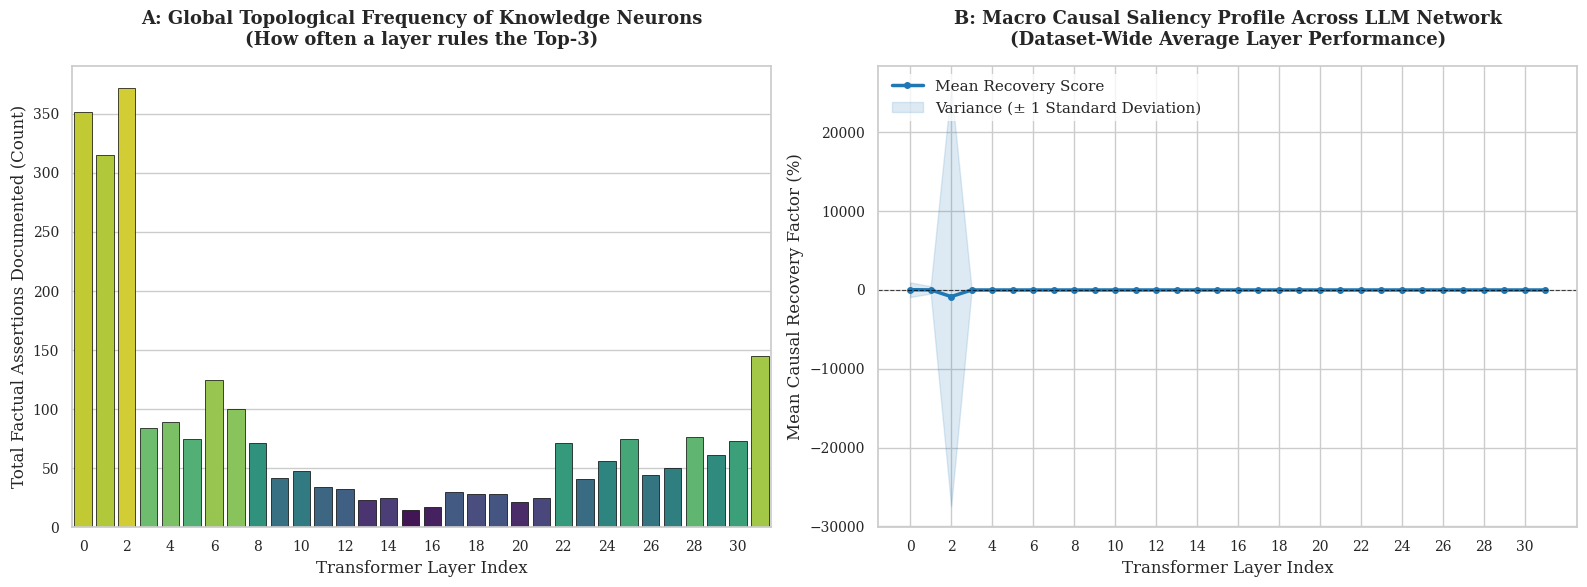

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic plotting style
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15
})

# Create a 1-row, 2-column dashboard layout
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PANEL A: Global Top-3 Layer Frequency Distribution

colors = sns.color_palette("viridis", len(summary_df))
# Rank color intensity by frequency
rank = summary_df['Top_3_Appearance_Frequency'].argsort().argsort()
palette = [colors[r] for r in rank]

sns.barplot(
    x='Layer', 
    y='Top_3_Appearance_Frequency', 
    data=summary_df, 
    palette=palette, 
    ax=ax1, 
    edgecolor='black', 
    linewidth=0.5
)
ax1.set_title("A: Global Topological Frequency of Knowledge Neurons\n(How often a layer rules the Top-3)", pad=15, fontweight='bold')
ax1.set_xlabel("Transformer Layer Index")
ax1.set_ylabel("Total Factual Assertions Documented (Count)")
ax1.set_xticks(range(0, 32, 2)) # Keep x-axis readable

# PANEL B: Macro Layer-Impact Profile (Mean ± Std Dev)
# Plot the mean recovery trend line
ax2.plot(
    summary_df['Layer'], 
    summary_df['Global_Mean_Recovery'], 
    color='#1f77b4', 
    linewidth=2.5, 
    label='Mean Recovery Score',
    marker='o',
    markersize=4
)

# Overlay the standard deviation as a shaded confidence band
ax2.fill_between(
    summary_df['Layer'], 
    summary_df['Global_Mean_Recovery'] - summary_df['Global_Std_Dev'], 
    summary_df['Global_Mean_Recovery'] + summary_df['Global_Std_Dev'], 
    color='#1f77b4', 
    alpha=0.15, 
    label='Variance (± 1 Standard Deviation)'
)

ax2.set_title("B: Macro Causal Saliency Profile Across LLM Network\n(Dataset-Wide Average Layer Performance)", pad=15, fontweight='bold')
ax2.set_xlabel("Transformer Layer Index")
ax2.set_ylabel("Mean Causal Recovery Factor (%)")
ax2.set_xticks(range(0, 32, 2))
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7) # Zero line index boundary
ax2.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# Optimize layout and boundaries
plt.tight_layout()

# Save the high-resolution vector image directly for your thesis PDF file
plt.savefig("../reports/figures/global_mechanistic_analysis_profile.pdf", dpi=300, bbox_inches='tight')
plt.savefig("../reports/figures/global_mechanistic_analysis_profile.png", dpi=300, bbox_inches='tight')

plt.show()